# Análisis de datos exploratorios (EDA)

Realizaremos un análisis de datos exploratorio para comprender las características generales del conjunto de datos e identificar patrones relevantes en el comportamiento de compra de los clientes.

El análisis incluirá:

* Distribución de ingresos.
* Distribución a clientes.
* Frecuencia de compra.
* Volumen de transacciones.
* Contribución a los ingresos por parte de los clientes.
* Distribución de valores de transacción.
* Identificación de posibles valores atípicos.

El objetivo de la EDA es comprender el conjunto de datos antes de realizar la segmentación a nivel de cliente e identificar patrones que puedan ser relevantes para el análisis RFM.


## Pregunta principal

> ¿Cómo podemos segmentar a los clientes en función de su **comportamiento de compra** para identificar a los clientes de alto valor y en riesgo, y qué estrategias de marketing se pueden implementar para mejorar la retención de clientes y aumentar los ingresos?

## Subpreguntas

### Valor para el cliente

* ¿Qué clientes son los más valiosos para la empresa?
* ¿Qué proporción de clientes genera la mayor parte de los ingresos totales de la empresa y qué porcentaje de los ingresos aportan?

### Fidelización del cliente

* ¿Qué clientes compran con más frecuencia y recientemente?
* ¿Qué clientes demuestran el mayor compromiso de compra?

### Posible inactividad

* ¿Qué clientes no han comprado durante un período prolongado?

### Comercialización

* ¿A qué segmentos de clientes deberían dirigirse los incentivos o promociones de fidelidad?
* ¿A qué clientes se debería dirigir campañas de reactivación para reducir la posible inactividad y mejorar la retención?

## Alcance

Nos centraremos en analizar las transacciones y los marcos de datos de los clientes de rfm para responder las preguntas principales y secundarias. Esto significa que no analizaremos otros marcos de datos ni fuentes de datos externas. El análisis se limitará a los datos disponibles y no incluirá ninguna recopilación de datos adicionales ni investigación externa. 

## Resumen

Usaremos los marcos de datos de transacciones y clientes de rfm para realizar la EDA y responder las preguntas principales y secundarias. El análisis proporcionará información sobre el comportamiento de los clientes, lo que nos permitirá identificar clientes de alto valor, clientes leales y aquellos en riesgo de volverse inactivos. Con base en estos conocimientos, podemos desarrollar estrategias de marketing específicas para mejorar la retención de clientes y aumentar los ingresos.

Además, eliminaremos los valores atípicos del marco de datos de transacciones para mejorar la distribución de las variables continuas y garantizar que el análisis no esté sesgado por valores extremos. Esto nos ayudará a comprender mejor las características generales del conjunto de datos e identificar patrones relevantes en el comportamiento de compra de los clientes.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use("ggplot")
sns.set_theme(style="darkgrid")
transactions = pd.read_csv("../../data/processed/prepared_transactions.csv")
customers = pd.read_csv("../../data/processed/prepared_customers.csv")

Eliminaremos cualquier valor atípico para mejorar la distribución de las variables continuas y asegurarnos de que el análisis no esté sesgado por valores extremos. Esto nos ayudará a comprender mejor las características generales del conjunto de datos e identificar patrones relevantes en el comportamiento de compra de los clientes.

### Nota importante

En el análisis de rfm utilizaremos estos datos, porque son necesarios para conocer el comportamiento de los clientes y segmentarlos en función de su comportamiento de compra. El análisis de rfm nos ayudará a identificar clientes de alto valor, clientes leales y aquellos en riesgo de volverse inactivos. Esta información se utilizará para desarrollar estrategias de marketing específicas para mejorar la retención de clientes y aumentar los ingresos.

In [28]:
Q1_quantity = transactions['quantity'].quantile(0.25)
Q3_quantity = transactions['quantity'].quantile(0.75)
IQR_quantity = Q3_quantity - Q1_quantity

Q1_unit_price = transactions['price'].quantile(0.25)
Q3_unit_price = transactions['price'].quantile(0.75)
IQR_unit_price = Q3_unit_price - Q1_unit_price

transactions = transactions[
    ((transactions['quantity'] >= Q1_quantity - 1.5 * IQR_quantity) &
     (transactions['quantity'] <= Q3_quantity + 1.5 * IQR_quantity)) &
    ((transactions['price'] >= Q1_unit_price - 1.5 * IQR_unit_price) &
     (transactions['price'] <= Q3_unit_price + 1.5 * IQR_unit_price))
]
transactions["total_price"] = transactions["quantity"] * transactions["price"]


Crearemos clientes nuevamente porque los valores atípicos afectaron la comprensión de esta EDA, por lo que para este análisis usaremos solo las transacciones válidas sin valores atípicos y luego crearemos los clientes rfm nuevamente para comprender mejor el comportamiento de los clientes.

In [29]:
customers_without_outliers = (
    transactions[
        (transactions["valid_transaction"] == True) |
        (transactions["is_discounted"] == True)
    ]
    .groupby("customer_id")
    .agg(
        recency=("days_since_last_purchase", "min"),
        frequency=("invoice", "nunique"),
        monetary=("total_price", "sum"),
        avg_order_value=("total_price", "mean"),
        avg_quantity=("quantity", "mean"),
        discount_rate=("is_discounted", "mean"),
    )
    .reset_index()
)

customers_without_outliers["recency"] = customers_without_outliers["recency"].astype(int)

In [30]:
customers_without_outliers.info()

<class 'pandas.DataFrame'>
RangeIndex: 4191 entries, 0 to 4190
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      4191 non-null   int64  
 1   recency          4191 non-null   int64  
 2   frequency        4191 non-null   int64  
 3   monetary         4191 non-null   float64
 4   avg_order_value  4191 non-null   float64
 5   avg_quantity     4191 non-null   float64
 6   discount_rate    4191 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 229.3 KB


In [31]:
transactions.info()

<class 'pandas.DataFrame'>
Index: 333046 entries, 0 to 391161
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   invoice                   333046 non-null  int64  
 1   stock_code                333046 non-null  str    
 2   description               333046 non-null  str    
 3   quantity                  333046 non-null  int64  
 4   invoice_date              333046 non-null  str    
 5   price                     333046 non-null  float64
 6   customer_id               333046 non-null  int64  
 7   country                   333046 non-null  str    
 8   is_cancellation           333046 non-null  bool   
 9   special_stock_code        333046 non-null  bool   
 10  valid_transaction         333046 non-null  bool   
 11  is_discounted             333046 non-null  bool   
 12  total_price               333046 non-null  float64
 13  last_purchase_date        333046 non-null  str    
 14  days

In [32]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 4335 entries, 0 to 4334
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      4335 non-null   int64  
 1   recency          4335 non-null   int64  
 2   frequency        4335 non-null   int64  
 3   monetary         4335 non-null   float64
 4   avg_order_value  4335 non-null   float64
 5   avg_quantity     4335 non-null   float64
 6   discount_rate    4335 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 237.2 KB


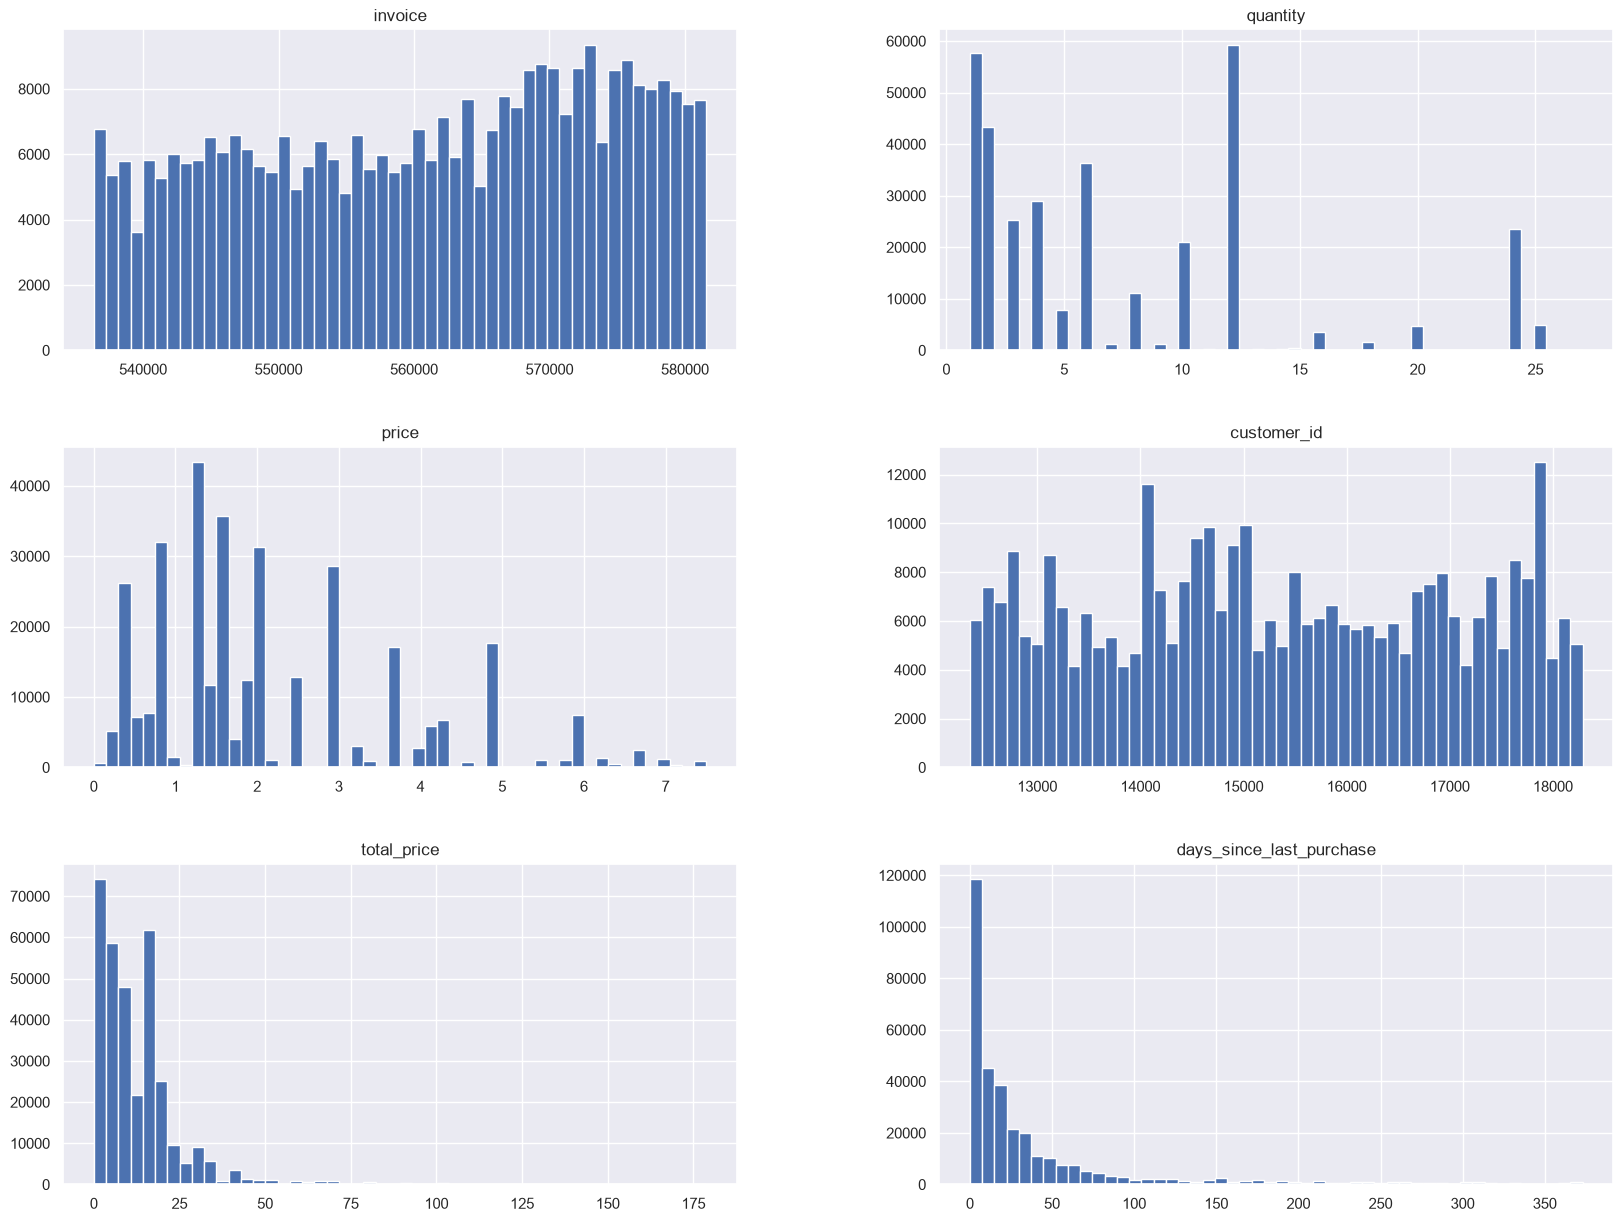

In [33]:
transactions.hist(bins=50, figsize=(20, 15))
plt.show()

In [34]:
skewness = transactions.select_dtypes("number").skew().sort_values(ascending=False)

skewness_df = pd.DataFrame({"skewness": skewness})

skewness_df

,skewness
total_price,3.250204
days_since_last_purchase,2.799541
quantity,1.191511
price,1.086640
customer_id,0.009088
invoice,-0.199667


## Resumen

- días_since_last_purchase: está sesgado a la derecha con **2.799541**, eso significa que la mayoría de los clientes tienen días bajos desde la última compra, pero hay algunos clientes con días muy altos desde la última compra.
- total_price: Está sesgado hacia la derecha con **3.250204**, eso significa que la mayoría de las transacciones tienen un precio total bajo, pero hay algunas transacciones con un precio total muy alto.
- cantidad: está sesgado hacia la derecha con **1.191511**, eso significa que la mayoría de las transacciones tienen una cantidad baja, pero hay algunas transacciones con una cantidad muy alta.
- precio: Está sesgado a la derecha con **1.086640**, eso significa que la mayoría de las transacciones tienen un precio bajo, pero hay algunas transacciones con un precio muy alto.

### Perspectivas

- La mayoría de los clientes tienen días bajos desde la última compra, pero hay algunos clientes con días muy altos desde la última compra. Esto significa que la mayoría de los clientes están activos, pero hay algunos clientes que están inactivos.

- La mayoría de las transacciones tienen un precio total bajo, pero hay algunas transacciones con un precio total muy alto. Esto significa que la mayoría de los clientes compran productos de bajo precio, pero hay algunos clientes que compran productos de alto precio (estos clientes son los más valiosos para la empresa).

- La mayoría de las transacciones tienen una cantidad baja, pero hay algunas transacciones con una cantidad muy alta. Esto significa que la mayoría de los clientes compran pequeñas cantidades de productos, pero hay algunos clientes que compran grandes cantidades de productos (estos clientes son los más leales a la empresa).

- La mayoría de las transacciones tienen un precio bajo, pero hay algunas transacciones con un precio muy alto. Esto significa que la mayoría de los clientes compran productos de bajo precio, pero hay algunos clientes que compran productos de alto precio (estos clientes son los más valiosos para la empresa).

In [35]:
transactions.describe().T

,count,mean,std,min,25%,50%,75%,max
invoice,333046.0,560807.143127,13116.800121,536365.000,549316.00,562163.00,572284.00,581587.0
quantity,333046.0,7.552644,6.777559,1.000,2.00,6.00,12.00,27.0
price,333046.0,2.194618,1.545978,0.001,1.25,1.65,2.95,7.5
customer_id,333046.0,15318.691676,1711.105231,12347.000,13988.00,15234.00,16814.00,18287.0
total_price,333046.0,12.907581,13.216422,0.001,3.95,10.15,17.40,178.8
days_since_last_purchase,333046.0,39.024222,64.401289,0.000,3.00,15.00,41.00,373.0


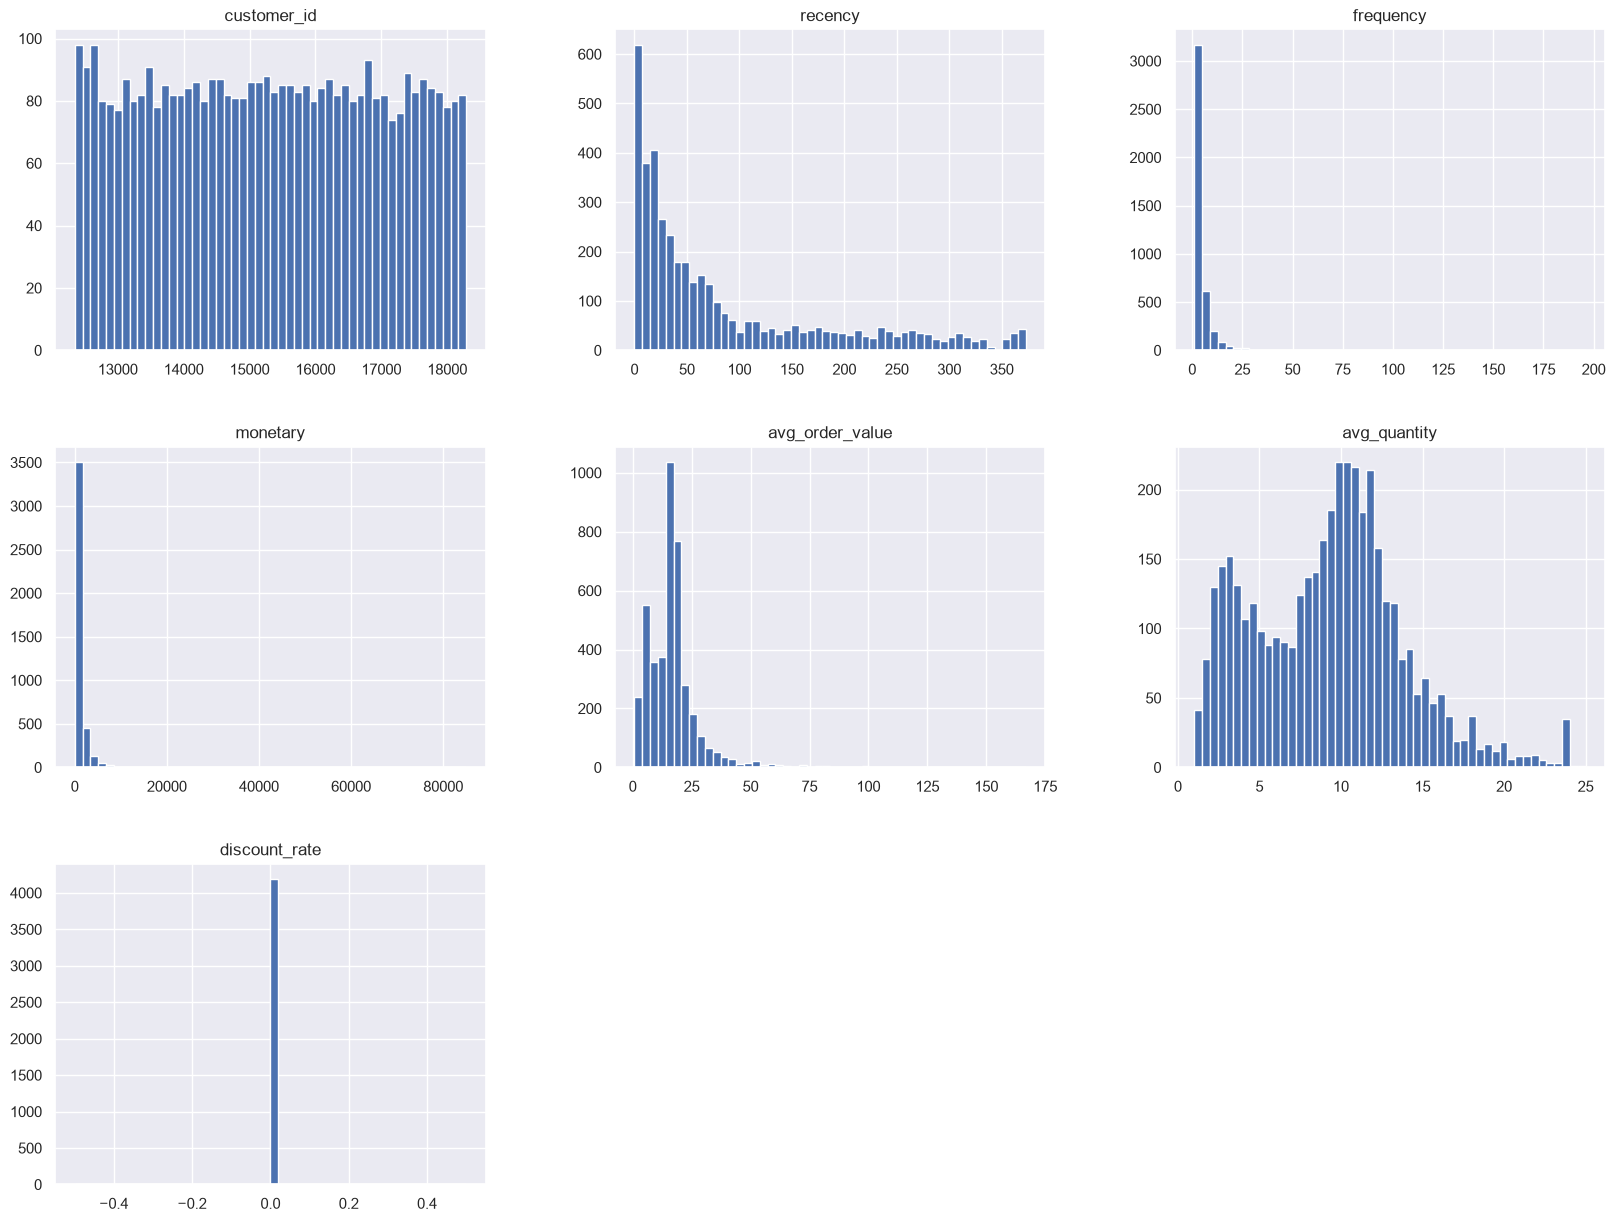

In [36]:
customers_without_outliers.hist(bins=50, figsize=(20, 15))
plt.show()

In [37]:
skewness = customers_without_outliers.select_dtypes("number").skew().sort_values(ascending=False)

skewness_df = pd.DataFrame({"skewness": skewness})

skewness_df

,skewness
monetary,17.573902
frequency,13.315857
avg_order_value,3.318013
recency,1.305717
avg_quantity,0.395496
customer_id,0.004944
discount_rate,0.000000


In [38]:
customers_without_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,4191.0,15290.900262,1719.057238,12347.000000,13809.500000,15281.000000,16770.5000,18287.00
recency,4191.0,87.200429,97.792933,0.000000,15.000000,45.000000,132.5000,373.00
frequency,4191.0,4.012408,7.015859,1.000000,1.000000,2.000000,4.0000,196.00
monetary,4191.0,1025.726123,2199.881327,1.900000,206.160000,465.970000,1126.2950,84980.89
avg_order_value,4191.0,16.801687,11.611985,0.747143,9.642335,16.055714,19.5566,166.80
avg_quantity,4191.0,9.278665,4.592489,1.000000,5.571429,9.600000,12.0000,25.00
discount_rate,4191.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.00


## Resumen

- **monetray**: Está sesgado a la derecha con **17.573902**, eso significa que la mayoría de los clientes tienen un valor monetario bajo, pero hay algunos clientes con un valor monetario muy alto.
- **frequency**: Está sesgado a la derecha con **13.315857**, eso significa que la mayoría de los clientes tienen un valor de frecuencia bajo, pero hay algunos clientes con un valor de frecuencia muy alto.
- **avg_order_value**: está sesgado hacia la derecha con **3.318013**, lo que significa que la mayoría de los clientes tienen un valor de pedido promedio bajo, pero hay algunos clientes con un valor de pedido promedio muy alto.
- **recency**: está sesgado hacia la derecha con **1.305717**, eso significa que la mayoría de los clientes tienen un valor de actualidad bajo, pero hay algunos clientes con un valor de actualidad muy alto.
- **avg_quantity**: está sesgado a la derecha con **0.395496**, lo que significa que la mayoría de los clientes tienen un valor de cantidad promedio bajo, pero hay algunos clientes con un valor de cantidad promedio muy alto.

### Perspectivas

- La mayoría de los clientes tienen un valor monetario bajo, pero hay algunos clientes con un valor monetario muy alto. Esto significa que la mayoría de los clientes no gastan mucho dinero, pero hay algunos clientes que gastan mucho dinero (estos clientes son los más valiosos para la empresa).

- Otros clientes tienen un valor de frecuencia bajo, pero hay algunos clientes con un valor de frecuencia muy alto. Esto significa que la mayoría de los clientes no compran con frecuencia, pero hay algunos clientes que compran con frecuencia (estos clientes son los más leales a la empresa).

- La mayoría de los clientes tienen un valor de pedido promedio bajo, pero hay algunos clientes con un valor de pedido promedio muy alto. Esto significa que la mayoría de los clientes no gastan mucho dinero por pedido, pero hay algunos clientes que gastan mucho dinero por pedido (estos clientes son los más valiosos para la empresa).

- La mayoría de los clientes tienen un valor de actualidad bajo, pero hay algunos clientes con un valor de actualidad muy alto. Esto significa que la mayoría de los clientes no están comprando recientemente, pero hay algunos clientes que sí están comprando recientemente (estos clientes son los más leales a la empresa).

- La mayoría de los clientes tienen un valor de cantidad promedio bajo, pero hay algunos clientes con un valor de cantidad promedio muy alto. Esto significa que la mayoría de los clientes no compran muchos productos por pedido, pero hay algunos clientes que compran muchos productos por pedido (estos clientes son los más leales a la empresa).

## Perspectivas críticas

- Como dijimos antes, la frecuencia es un derecho sesgado con **13.315857**, esto es malo porque significa que la mayoría de los clientes no compran con frecuencia, aunque hay algunos clientes que compran con frecuencia que nos ayudan a comprender quiénes son los clientes más leales a la empresa, y podemos usar esta información para desarrollar estrategias de marketing dirigidas para mejorar la retención de clientes y aumentar los ingresos.

## Valor para el cliente

Intentaremos responder las preguntas sobre los clientes que realizaron la mayor cantidad de compras y los clientes que generaron la mayor cantidad de ingresos para la empresa, y también los clientes que realizaron la mayor cantidad de compras con descuento y los clientes que obtuvieron la mayor cantidad de ingresos con descuento.

### ¿Qué clientes son los más valiosos para la empresa?

Intentaremos responder esta pregunta observando a los clientes que realizaron la mayor cantidad de compras (por ejemplo, los clientes del P90).

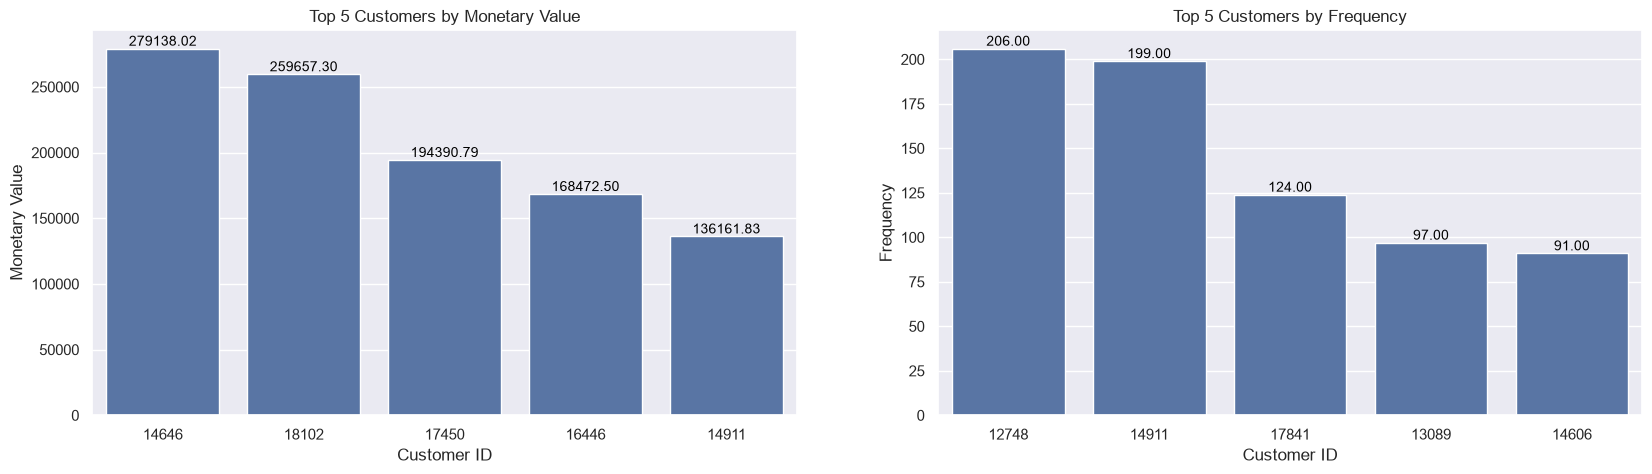

In [39]:
fig , axes = plt.subplots(1, 2, figsize=(20, 5))

top_5_customers_monetary = customers.nlargest(5, "monetary")[["customer_id", "monetary"]]
top_5_customers_frequency = customers.nlargest(5, "frequency")[["customer_id", "frequency"]]
top_5_customers_recency = customers.nsmallest(5, "recency")[["customer_id", "recency"]]
columns = [{
    "column" : "monetary",
    "data" : top_5_customers_monetary,
    "title" : "Top 5 Customers by Monetary Value",
    "xlabel" : "Customer ID",
    "ylabel" : "Monetary Value"
},
{
    "column" : "frequency",
    "data" : top_5_customers_frequency,
    "title" : "Top 5 Customers by Frequency",
    "xlabel" : "Customer ID",
    "ylabel" : "Frequency"
}]


for i, column in enumerate(columns):

    sns.barplot(
        x="customer_id",
        y=column["column"],
        data=column["data"],
        ax=axes[i],
        order=column["data"]["customer_id"]
    )

    axes[i].bar_label(axes[i].containers[0], fmt='%.2f', label_type='edge', fontsize=10, color='black')
    axes[i].set_title(column["title"])
    axes[i].set_xlabel(column["xlabel"])
    axes[i].set_ylabel(column["ylabel"])

## Resumen

Podemos visualizar los 5 clientes principales por valor monetario utilizando un diagrama de barras. Esto nos ayudará a identificar a los clientes más valiosos para la empresa.

Algunas ideas importantes del diagrama de barras:

- El cliente más valioso de la empresa es el **Customer ID 14646**, con un valor monetario de $279,138.02. Este cliente ha generado el mayor ingreso total y ha contribuido significativamente a los ingresos generales de la empresa, seguido por el Customer ID 18102, con un valor monetario de $259,657.30. En conjunto, estos dos clientes representan una parte significativa de los ingresos totales de la empresa.

- Los clientes más frecuentes de la empresa son **Customer ID 12748** con una frecuencia de **206** y **Customer ID 14911** con una frecuencia de **199**. Estos clientes han realizado el mayor número de compras y demuestran un fuerte compromiso de compra.

- Algo interesante en el gráfico se trata de **Customer 14911**, este cliente es el quinto cliente más valioso de la empresa con un valor monetario de **$136161.83**, pero este cliente es el segundo cliente más frecuente de la empresa con una frecuencia de **199**. Esto significa que este cliente compra con frecuencia, pero no gasta mucho dinero por pedido, lo que indica que este cliente es leal a la empresa, pero no valioso.

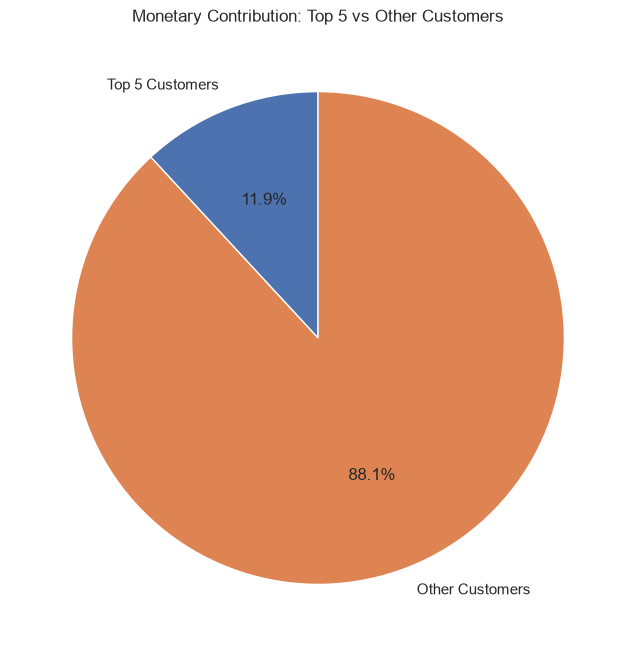

In [40]:
plt.figure(figsize=(12, 8))

customers_most_valuable = customers.nlargest(5, "monetary")

customers_others = customers[
    ~customers["customer_id"].isin(customers_most_valuable["customer_id"])
]

most_valuable_total = customers_most_valuable["monetary"].sum()
others_total = customers_others["monetary"].sum()

values = [most_valuable_total, others_total]
labels = ["Top 5 Customers", "Other Customers"]


plt.pie(
    values,
    labels=labels,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Monetary Contribution: Top 5 vs Other Customers")

plt.show()

## Resumen

Sólo los 5 principales clientes forman parte del 11,9% del total de clientes en contribución monetaria, lo que significa que un pequeño porcentaje de clientes es responsable de una gran parte de los ingresos de la empresa. Esta es una idea importante para la empresa, ya que resalta la importancia de retener a estos clientes de alto valor y desarrollar estrategias de marketing específicas para aumentar su compromiso y gasto.

90th Percentile of Monetary: 3560.08
Top 10% Customers: 435
Bottom 90% Customers: 3900
Total Customers: 4335
Percentage of Top 10% Customers: 10.03%


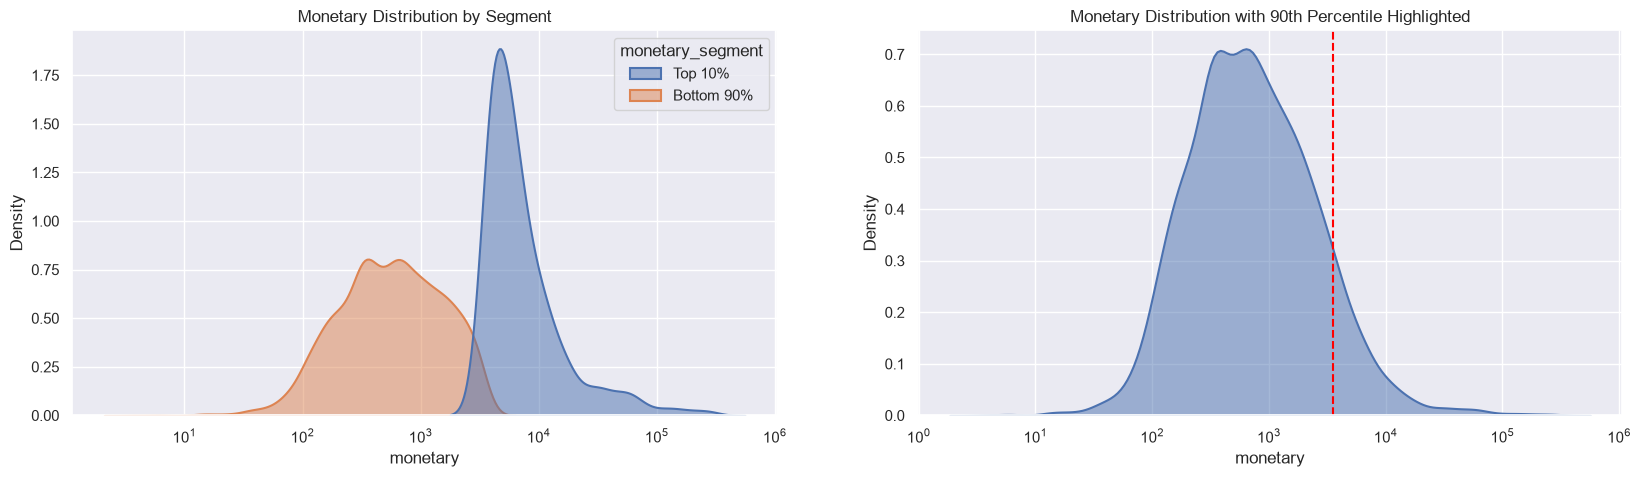

In [41]:
p90 = customers["monetary"].quantile(0.9)
customers["monetary_segment"] = np.where(customers["monetary"] >= p90, "Top 10%", "Bottom 90%")

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

sns.kdeplot(
    data=customers,
    x="monetary",
    hue="monetary_segment",
    fill=True,
    common_norm=False,
    alpha=0.5,
    linewidth=1.5,
    log_scale=True,
    ax=axes[0]
)
sns.kdeplot(
    data=customers,
    x="monetary",
    fill=True,
    common_norm=False,
    alpha=0.5,
    linewidth=1.5,
    log_scale=True,
    ax=axes[1]
)

axes[1].axvline(p90, color='red', linestyle='--', label=f'90th Percentile: {p90:.2f}')

axes[1].set_title("Monetary Distribution with 90th Percentile Highlighted")
axes[0].set_title("Monetary Distribution by Segment")


print(f"90th Percentile of Monetary: {p90:.2f}")
print(f"Top 10% Customers: {len(customers[customers['monetary_segment'] == 'Top 10%'])}")
print(f"Bottom 90% Customers: {len(customers[customers['monetary_segment'] == 'Bottom 90%'])}")
print(f"Total Customers: {len(customers)}")
print(f"Percentage of Top 10% Customers: {len(customers[customers['monetary_segment'] == 'Top 10%']) / len(customers) * 100:.2f}%")

plt.show()

## Resumen

En el primer gráfico podemos ver la distribución de dos tipos de clientes, "90% inferior" y "10% superior", en función de su valor monetario. Podemos analizar que el 10% superior tiende a tener una distribución sesgada hacia la derecha, lo que reafirma que un pequeño porcentaje de clientes es responsable de una gran parte de los ingresos de la empresa. Esta es una idea importante para la empresa, ya que resalta la importancia de retener a estos clientes de alto valor y desarrollar estrategias de marketing específicas para aumentar su compromiso y gasto.

En el segundo gráfico podemos ver el P90 con el valor de **$3560.08**, lo que significa que el 90% de los clientes tienen un valor monetario menor a este valor, y el 10% de los clientes tienen un valor monetario mayor a este valor. Por lo tanto, estos clientes son el núcleo de los ingresos de la empresa.

### ¿Qué proporción de clientes genera la mayor parte de los ingresos totales de la empresa y qué porcentaje de los ingresos aportan?

Segmentamos a los clientes en dos grupos según su valor monetario: "90% inferior" y "10% superior". Luego calculamos los ingresos totales generados por cada grupo y los comparamos con los ingresos generales.

Top 10% share: 61.46%
Bottom 90% share: 38.54%
Total Customers: 4335
Top 10% Customers: 435
Bottom 90% Customers: 3900


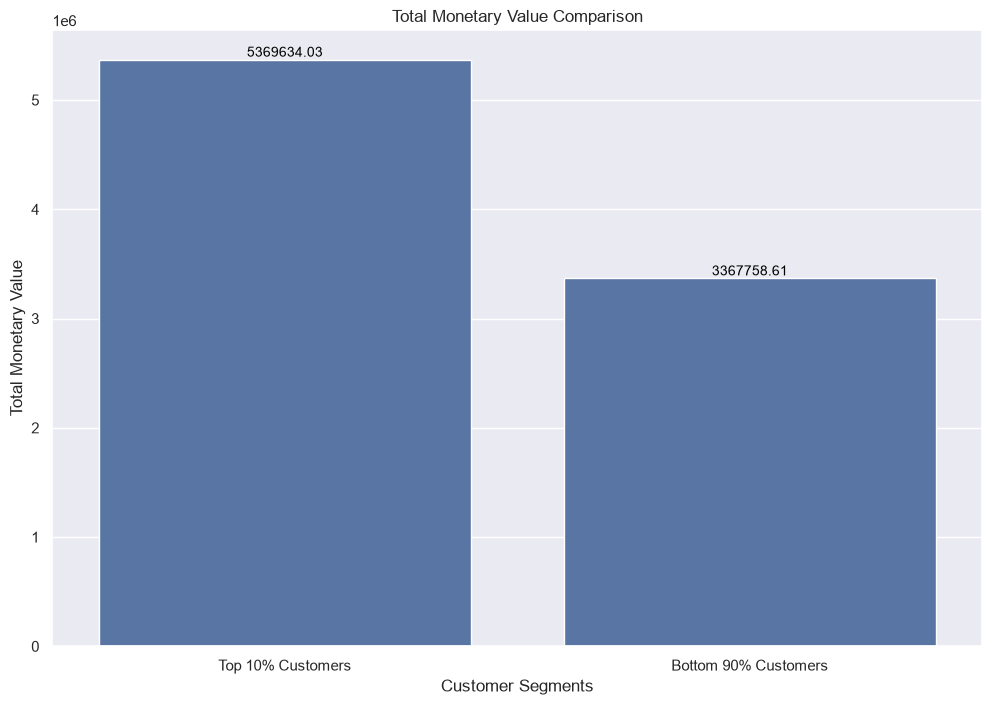

In [42]:
plt.figure(figsize=(12, 8))

highest_value_customers = customers[customers["monetary_segment"] == "Top 10%"].copy()
other_customers = customers[customers["monetary_segment"] == "Bottom 90%"].copy()

sum_highest_value = highest_value_customers["monetary"].sum()
sum_other_value = other_customers["monetary"].sum()

ax = sns.barplot(
    x=["Top 10% Customers", "Bottom 90% Customers"],
    y=[sum_highest_value, sum_other_value],
    
)

ax.set_title("Total Monetary Value Comparison")
ax.set_ylabel("Total Monetary Value")
ax.set_xlabel("Customer Segments")

ax.bar_label(ax.containers[0], fmt='%.2f', label_type='edge', fontsize=10, color='black')


total_monetary = sum_highest_value + sum_other_value

top_share = sum_highest_value / total_monetary * 100
bottom_share = sum_other_value / total_monetary * 100

print(f"Top 10% share: {top_share:.2f}%")
print(f"Bottom 90% share: {bottom_share:.2f}%")
print(f"Total Customers: {len(customers)}")
print(f"Top 10% Customers: {len(highest_value_customers)}")
print(f"Bottom 90% Customers: {len(other_customers)}")

plt.show()

## Resumen

El 10% superior de los clientes representa el **61,46%** de los ingresos totales, lo que significa que un pequeño porcentaje de clientes es responsable de una gran parte de los ingresos de la empresa. Además, estos clientes de alto valor representan sólo 435 clientes, lo que destaca la fuerte concentración de ingresos entre un grupo de clientes relativamente pequeño.

## Fidelización del cliente

Intentaremos responder por qué los clientes son más leales que otros en la empresa y también intentaremos responder qué clientes son los más leales a la empresa y cuáles son los menos leales a la empresa.

### ¿Qué clientes compran con más frecuencia y recientemente?

Vamos a analizar los clientes que compran con mayor frecuencia y recientemente, y también los clientes que compran con menor frecuencia y recientemente. Esto nos ayudará a comprender qué clientes son los más leales a la empresa y qué clientes son los menos leales a la empresa.

In [43]:
customers.head()

,customer_id,recency,frequency,monetary,avg_order_value,avg_quantity,discount_rate,monetary_segment
0,12346,325,1,77183.60,77183.600000,74215.000000,0.0,Top 10%
1,12347,1,7,4310.00,23.681319,13.505495,0.0,Top 10%
2,12348,74,4,1437.24,53.231111,86.370370,0.0,Bottom 90%
3,12349,18,1,1457.55,20.243750,8.750000,0.0,Bottom 90%
4,12350,309,1,294.40,18.400000,12.250000,0.0,Bottom 90%


Top 10% of customers by recency: 483 (11.14%)
Top 10% of customers by frequency: 458 (10.57%)
Total number of customers: 4335


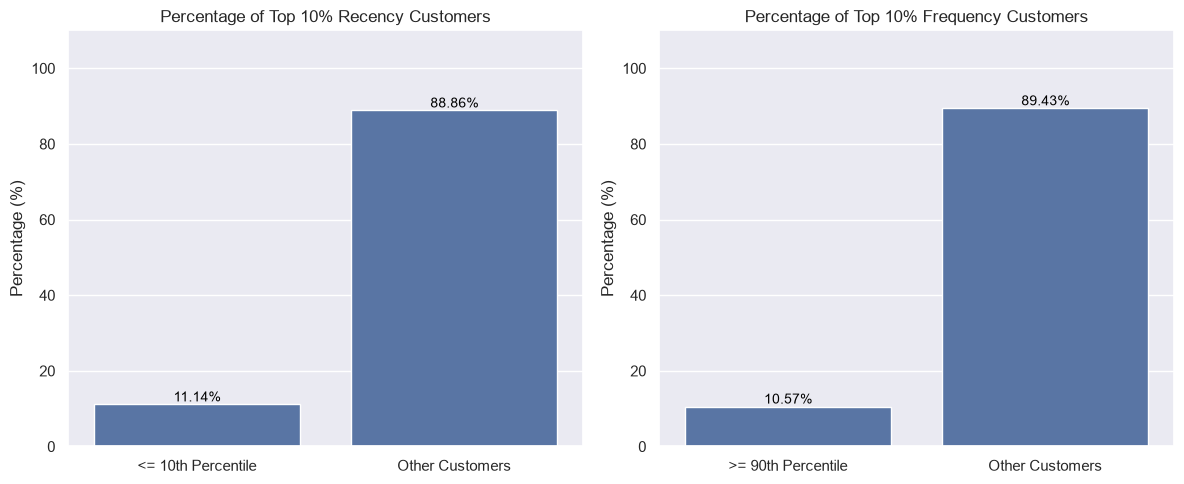

In [44]:

recency_customers = customers[customers["recency"] <= customers["recency"].quantile(0.1)][["customer_id", "recency"]]
frequency_customers = customers[customers["frequency"] >= customers["frequency"].quantile(0.9)][["customer_id", "frequency"]]

quantity_recency_customers = len(recency_customers)
quantity_frequency_customers = len(frequency_customers)

percentage_recency_customers = (quantity_recency_customers / len(customers)) * 100
percentage_frequency_customers = (quantity_frequency_customers / len(customers)) * 100

print(f"Top 10% of customers by recency: {quantity_recency_customers} ({percentage_recency_customers:.2f}%)")
print(f"Top 10% of customers by frequency: {quantity_frequency_customers} ({percentage_frequency_customers:.2f}%)")
print(f"Total number of customers: {len(customers)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    x=["<= 10th Percentile", "Other Customers"],
    y=[percentage_recency_customers, 100 - percentage_recency_customers],
    ax=axes[0],
)
axes[0].set_title("Percentage of Top 10% Recency Customers")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, 110) 
axes[0].bar_label(axes[0].containers[0], fmt='%.2f%%', label_type='edge', fontsize=10, color='black')

sns.barplot(
    x=[">= 90th Percentile", "Other Customers"],
    y=[percentage_frequency_customers, 100 - percentage_frequency_customers],
    ax=axes[1]
)
axes[1].set_title("Percentage of Top 10% Frequency Customers")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 110)  
axes[1].bar_label(axes[1].containers[0], fmt='%.2f%%', label_type='edge', fontsize=10, color='black')

plt.tight_layout()
plt.show()

## Resumen

**Análisis de recencia**: Los clientes que se encuentran en el **percentil ≤ 10** representan el **11,14 %** de la base total de clientes. Debido a que valores más bajos de recencia indican compras más recientes, estos clientes activos demuestran un alto nivel de compromiso y representan una parte importante de la actividad comercial reciente.

**Análisis de frecuencia**: Los clientes que se encuentran en el **percentil ≥ 90** representan el **10,57 %** de la base total de clientes. Este grupo constituye el segmento principal de compradores leales y recurrentes, ya que realizan compras con una frecuencia significativamente mayor que el cliente promedio.

### ¿Qué clientes demuestran el mayor compromiso de compra?

Iremos a analizar los clientes con diferentes clasificaciones de RFM, tenga en cuenta que esto es solo un resumen del análisis, y analizaremos más a los clientes con K-means Clustering más adelante en las siguientes secciones.

Number of Champions: 802


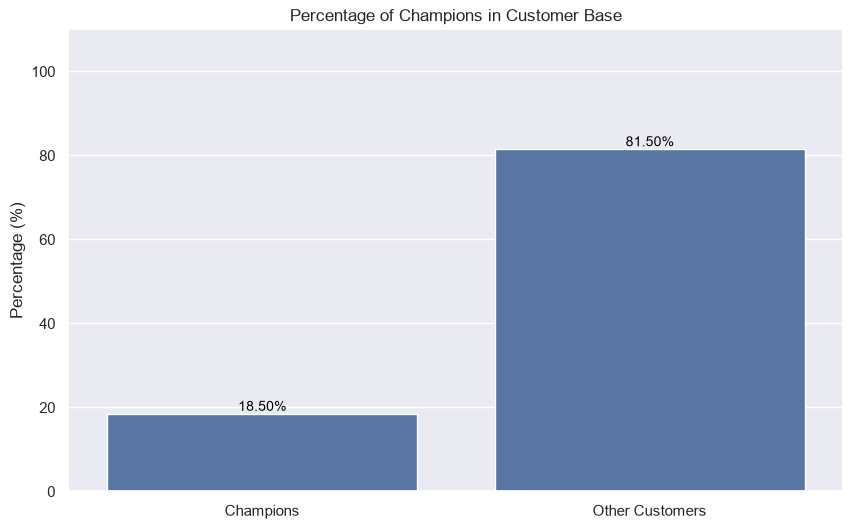

In [45]:
plt.figure(figsize=(10, 6))

customers['R_Score'] = pd.qcut(customers['recency'], 5, labels=[5, 4, 3, 2, 1])
customers['F_Score'] = pd.qcut(customers['frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
customers['M_Score'] = pd.qcut(customers['monetary'], 5, labels=[1, 2, 3, 4, 5])

customers['RFM_Score'] = customers['R_Score'].astype(str) + customers['F_Score'].astype(str) + customers['M_Score'].astype(str)

champions = customers[(customers['R_Score'] >= 4) & (customers['F_Score'] >= 4) & (customers['M_Score'] >= 4)]
print(f"Number of Champions: {len(champions)}")

champions_percentage = (len(champions) / len(customers)) * 100

ax = sns.barplot(
    x=["Champions", "Other Customers"],
    y=[champions_percentage, 100 - champions_percentage],
)

ax.set_title("Percentage of Champions in Customer Base")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 110)
ax.bar_label(ax.containers[0], fmt='%.2f%%', label_type='edge', fontsize=10, color='black')

plt.show()

## Resumen

El **18,50%** de los clientes son campeones, son los más reales porque tienen la mayor puntuación RFM, lo que indica su alto valor para el negocio. Además, esto significa que estos clientes están muy comprometidos y demuestran un fuerte comportamiento de compra, lo que los convierte en un segmento valioso para estrategias de marketing dirigidas.

## Segmentación de clientes basada en análisis RFM

- **Campeones (R ≥ 4, F ≥ 4, M ≥ 4)**: Clientes que han comprado recientemente, compran con frecuencia y tienen un alto valor monetario. Se encuentran entre los clientes más valiosos de la empresa y deben ser recompensados ​​con beneficios exclusivos y programas de fidelización.

- **Gigantes durmientes (R = 1–2, F ≥ 4, M ≥ 4)**: Clientes que no han comprado recientemente pero históricamente han comprado con frecuencia y gastado una cantidad significativa. Representan una valiosa oportunidad de volver a comprometerse.

- **Clientes en Riesgo (R = 1, F ≥ 4)**: Clientes que no han comprado recientemente pero tienen una frecuencia de compra alta. Es posible que corran el riesgo de perder ventas y se les debe dirigir promociones personalizadas o campañas de recuperación.

- **Potencialmente inactivos (R = 1, F = 1–2, M = 1–2)**: Clientes que no han comprado recientemente y tienen una frecuencia de compra y un valor monetario relativamente bajos. Corren el riesgo de volverse inactivos y pueden requerir estrategias de reactivación.

- **Clientes de alto valor (R ≥ 3, F ≥ 4, M ≥ 4)**: Clientes que tienen puntuaciones recientes, de frecuencia y monetarias relativamente altas. Representan una fuente importante de ingresos y deben recibir incentivos de lealtad para fomentar el compromiso continuo.

- **Leales potenciales (R ≥ 3, F = 3–4, M ≥ 3)**: Clientes que han comprado hace relativamente poco tiempo y muestran una frecuencia de compra y un valor monetario de moderado a alto. Tienen el potencial de convertirse en clientes muy leales y se les puede fomentar mediante promociones personalizadas e incentivos de fidelidad.

- **Otros Clientes**: Clientes que no cumplen con los criterios para los segmentos anteriores. Su comportamiento puede estar menos claramente definido y puede analizarse más a fondo para identificar oportunidades adicionales.

In [46]:
customers["segment"] = np.where(
# Campeones: gasto reciente, frecuente y elevado
    (customers["R_Score"] >= 4) &
    (customers["F_Score"] >= 4) &
    (customers["M_Score"] >= 4),
    "Champions",

    np.where(
# Gigantes durmientes: gasto no reciente, frecuente y elevado
        (customers["R_Score"].isin([1, 2])) &
        (customers["F_Score"] >= 4) &
        (customers["M_Score"] >= 4),
        "Sleeping Giants",

        np.where(
# En Riesgo: no reciente, pero sí frecuente
            (customers["R_Score"] == 1) &
            (customers["F_Score"] >= 4),
            "At Risk",

            np.where(
# Potencialmente inactivo: no reciente, baja frecuencia y bajo gasto
                (customers["R_Score"] == 1) &
                (customers["F_Score"].isin([1, 2])) &
                (customers["M_Score"].isin([1, 2])),
                "Potentially Inactive",

                np.where(
# Clientes de alto valor: gasto elevado, relativamente reciente y frecuente
                    (customers["R_Score"] >= 3) &
                    (customers["F_Score"] >= 4) &
                    (customers["M_Score"] >= 4),
                    "High-Value Customers",

                    np.where(
# Leales potenciales: recientes y moderadamente frecuentes
                        (customers["R_Score"] >= 3) &
                        (customers["F_Score"].isin([3, 4])) &
                        (customers["M_Score"] >= 3),
                        "Potential Loyalists",

                        "Other Customers"
                    )
                )
            )
        )
    )
)

In [52]:
customers["segment"].value_counts(normalize=True) * 100

segment
Other Customers         57.462514
Champions               18.500577
Potentially Inactive    12.825836
Potential Loyalists     10.380623
At Risk                  0.830450
Name: proportion, dtype: float64

## Inactividad potencial

Descubriremos por qué algunos clientes muestran patrones de comportamiento asociados con una posible inactividad y qué clientes no han comprado durante un período prolongado. Esto nos ayudará a comprender qué clientes corren el riesgo de volverse inactivos y cuáles corren el riesgo de abandonar.

### ¿Qué clientes no han comprado durante un período prolongado?

Analizaremos el comportamiento de los clientes e identificaremos aquellos que no han comprado durante un período prolongado. Esto nos ayudará a comprender qué clientes corren el riesgo de volverse inactivos y cuáles corren el riesgo de abandonar.

Vamos a dividir a los clientes en tres grupos:

- **Alta actualidad + baja frecuencia (potencialmente inactivo)** -> Estos clientes no han comprado recientemente y tienen una baja frecuencia de compras. Corren el riesgo de volverse inactivos y pueden requerir estrategias de reactivación para animarlos a realizar una compra.

- **Alta actualidad + alto valor monetario (gigantes durmientes)** -> Estos clientes no han comprado recientemente pero tienen un valor monetario alto. Proporcionan a la empresa unos ingresos elevados, pero corren el riesgo de volverse inactivos y pueden requerir estrategias de marketing específicas para animarles a realizar una compra.

- **Alta actualidad + alta frecuencia (En riesgo)** -> Estos clientes no han comprado recientemente pero tienen una alta frecuencia de compras. Corren el riesgo de perder ventas y pueden requerir estrategias de marketing específicas para animarlos a realizar una compra.

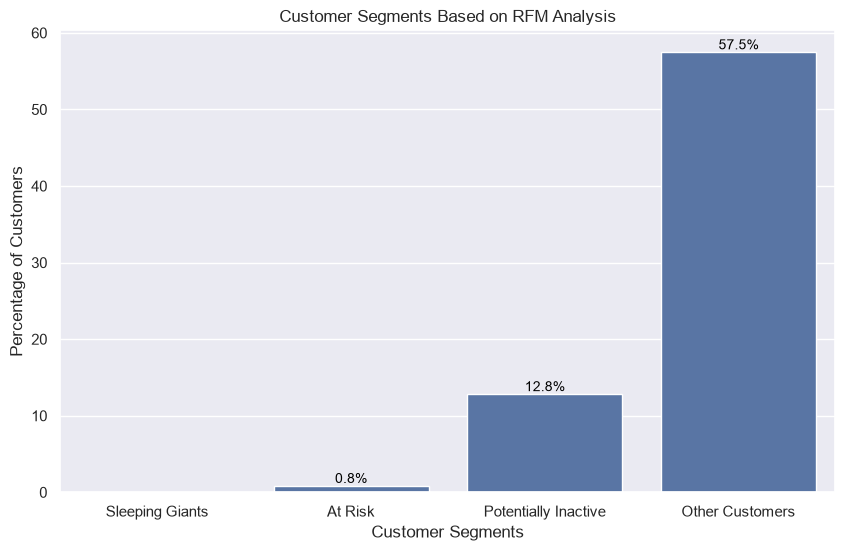

In [54]:
plt.figure(figsize=(10, 6))

total_customers = len(customers)


ax = sns.countplot(data=customers, x="segment", order=["Sleeping Giants" ,"At Risk", "Potentially Inactive", "Other Customers"] , stat="percent")
ax.set_title("Customer Segments Based on RFM Analysis")
ax.set_xlabel("Customer Segments")
ax.set_ylabel("Percentage of Customers")

ax.bar_label(ax.containers[0], fmt='%.1f%%', label_type='edge', fontsize=10, color='black')

plt.show()

## Resumen

Analizaremos estos tres segmentos de clientes para comprender su comportamiento e identificar a los clientes que corren el riesgo de volverse inactivos o abandonarse. Este análisis nos ayudará a desarrollar estrategias de marketing específicas para mejorar la retención de clientes y aumentar los ingresos.

- **Gigantes durmientes (0% de los clientes)** → Ningún cliente pertenece a este segmento, lo que significa que actualmente no hay clientes que tengan una alta frecuencia de compra y un alto valor monetario y al mismo tiempo tengan una baja antigüedad. Esto sugiere que la empresa no tiene actualmente un grupo significativo de clientes de alto valor en riesgo de quedar inactivos.

- **En riesgo (0,8% de los clientes)** → Este es un segmento relativamente pequeño, lo que significa que el riesgo general para el negocio es limitado. Sin embargo, estos clientes no han comprado recientemente, por lo que deben ser monitoreados y dirigidos a campañas de reactivación para evitar una mayor inactividad o abandono.

- **Potencialmente Inactivo (12,8% de los clientes)** → Este es el segmento más grande de los tres y por lo tanto merece mayor atención. Estos clientes no han comprado recientemente y tienen un gasto relativamente bajo, lo que indica un mayor riesgo de volverse inactivos. Se deben considerar estrategias de reactivación para alentarlos a comprar nuevamente antes de que abandonen.

En general, el segmento Potencialmente Inactivo debería ser la principal prioridad debido a su tamaño, mientras que los Gigantes Durmientes representan la oportunidad más valiosa de volver a interactuar.

## Comercialización

Analizaremos a los clientes para identificar a qué segmentos de clientes se les debe dirigir incentivos o promociones de lealtad, a qué segmentos de clientes se les deben dirigir campañas de marketing personalizadas para aumentar el compromiso y el gasto, y a qué clientes se les deben dirigir campañas de reincorporación para reducir la posible inactividad y mejorar la retención.

### ¿A qué segmentos de clientes deberían dirigirse los incentivos o promociones de fidelidad?

- **Clientes de alto valor (R ≥ 3, F ≥ 4, M ≥ 4)**: Clientes con puntajes monetarios y de frecuencia altos que han comprado relativamente recientemente. Deben ser recompensados ​​con programas de fidelización, beneficios exclusivos o promociones personalizadas para fomentar la continuidad del negocio y fortalecer la retención de clientes.

- **Campeones (R ≥ 4, F ≥ 4, M ≥ 4)**: Clientes que compran con frecuencia, gastan una cantidad significativa y han comprado recientemente. Estos se encuentran entre los clientes más valiosos de la empresa y se les debe ofrecer recompensas exclusivas, acceso temprano a los productos y beneficios de fidelidad premium.

- **Leales potenciales (R ≥ 3, F ≥ 3, M ≥ 3)**: Clientes con puntuaciones recientes y de frecuencia relativamente altas que muestran potencial para convertirse en clientes leales. Las promociones específicas y los incentivos de fidelidad pueden animarles a aumentar la frecuencia de sus compras y sus gastos.

- **Clientes en riesgo (R = 1, F ≥ 4)**: Clientes que no han comprado recientemente pero históricamente han comprado con frecuencia. Los descuentos personalizados o las campañas de recuperación pueden animarles a volver.

- **Gigantes durmientes (R = 1–2, F ≥ 4, M ≥ 4)**: Clientes que no han comprado recientemente pero tienen un valor monetario alto. Las promociones dirigidas y los incentivos personalizados podrían ayudar a volver a atraerlos y recuperar ingresos potenciales.

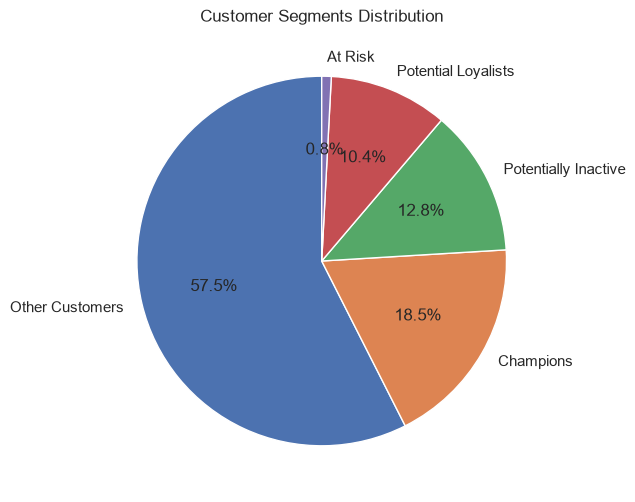

In [59]:


fig , ax = plt.subplots(figsize=(10, 6))

ax.pie(
    customers["segment"].value_counts(),
    labels=customers["segment"].value_counts().index,
    autopct="%.1f%%",
    startangle=90
)

ax.set_title("Customer Segments Distribution")

plt.show()

## Resumen

Deberíamos centrarnos en dirigirnos a los Campeones (18,5%) y a los Leales Potenciales (10,4%) con incentivos o promociones de fidelidad, ya que representan los segmentos de clientes más valiosos y comprometidos. Además, deberíamos considerar dirigirnos a Clientes en riesgo (0,8%) y Gigantes durmientes (0%) con campañas de marketing personalizadas para fomentar la reincorporación y evitar una posible inactividad o abandono.

### ¿A qué clientes se debería dirigir campañas de reactivación para reducir la posible inactividad y mejorar la retención?

Deberíamos centrarnos en apuntar al segmento potencialmente inactivo (12,8%) con campañas de reactivación para reducir la posible inactividad y mejorar la retención. Estos clientes no han comprado recientemente y tienen un gasto relativamente bajo, lo que indica un mayor riesgo de volverse inactivos. Se deben considerar estrategias de reactivación para alentarlos a comprar nuevamente antes de que abandonen.

# Análisis de datos exploratorios (EDA) - Conclusión

## Resumen ejecutivo

Esta EDA reveló información importante sobre el comportamiento de compra de los clientes, la concentración de ingresos y el valor para el cliente. El análisis RFM también proporcionó un marco inicial basado en reglas para identificar segmentos de clientes y desarrollar estrategias de marketing específicas. Estos hallazgos servirán como base para el posterior análisis de segmentación de clientes basado en datos utilizando la agrupación K-Means.

## Hallazgos clave

### 1. **Concentración de ingresos**

- **El 10% superior de los clientes genera el 61,46% de los ingresos totales**, lo que representa solo 435 clientes.
- El 90% restante de clientes aporta el 38,54% de los ingresos totales.
- Esto indica una alta concentración de ingresos entre un grupo relativamente pequeño de clientes, destacando la importancia de retener y desarrollar clientes de alto valor.
- Al mismo tiempo, esta concentración representa una oportunidad para incrementar el valor generado por una base de clientes más amplia.

### 2. **Segmentación inicial de clientes basada en RFM**

El análisis RFM proporcionó un marco inicial para comprender el comportamiento de **4335 clientes** según sus puntuaciones de actualidad, frecuencia y monetaria.

| Segmento | Porcentaje | Características clave | Prioridad |
|---|---:|---|---|
| **Campeones** | 18,5% | Gasto reciente, frecuente y elevado | ⭐⭐⭐ Recompensa y retiene |
| **Posibles leales** | 10,4% | Reciente, frecuencia moderada, buen gasto | ⭐⭐ Nutrir |
| **Otros clientes** | 57,5% | Comportamientos mixtos | ⭐ Monitorear |
| **Potencialmente inactivo** | 12,8% | No reciente, baja frecuencia, bajo gasto | ⚠️ Volver a participar |
| **En riesgo** | 0,8% | No reciente, alta frecuencia | ⚠️ Recuperación |
| **Gigantes Durmientes** | 0% | Ningún cliente cumple los criterios | — |

Estos segmentos deben considerarse una **segmentación inicial basada en reglas**, en lugar de clústeres basados ​​en datos. Los criterios se definieron utilizando puntuaciones de RFM y se evaluarán más a fondo mediante la agrupación de K-Means.

### 3. **Patrones de comportamiento de compra**

- Las distribuciones de **Recienteidad, Frecuencia, Monetaria y Cantidad** están sesgadas hacia la derecha, lo que indica que el comportamiento del cliente no está distribuido uniformemente.
- La mayoría de los clientes realizan relativamente menos compras y generan un menor valor monetario, mientras que un grupo más pequeño de clientes representa una proporción desproporcionadamente grande de los ingresos.
- Esto sugiere una oportunidad para desarrollar clientes de valor medio y bajo y al mismo tiempo proteger a los clientes más valiosos de la empresa.

**Principales clientes frecuentes:**
- Aproximadamente **10,57% de los clientes** se encuentran dentro del grupo de mayor frecuencia.
- Estos clientes realizan **206+ compras**, en comparación con un promedio de aproximadamente 7 compras.
- Esto indica un pequeño grupo de clientes muy frecuentes con un fuerte compromiso de compra.

**Clientes recientes:**
- Aproximadamente **11,14% de los clientes** pertenecen al grupo más reciente.
- Estos clientes compraron hace relativamente poco tiempo, lo que indica un compromiso actual más fuerte con la empresa.

### 4. **Riesgo potencial del cliente**

- **12,8% de los clientes** están clasificados como Potencialmente Inactivos según las reglas RFM iniciales. Esto representa el segmento de riesgo identificado más grande y puede requerir estrategias de reactivación.
- **0.8% de los clientes** están clasificados como En Riesgo, lo que representa clientes con alta frecuencia histórica de compra que no han comprado recientemente.
- **Ningún cliente fue clasificado como Gigante Durmiente**, lo que significa que ningún cliente cumplió simultáneamente con los criterios de baja actualidad, alta frecuencia y alto valor monetario.
- El tamaño relativamente pequeño del segmento En Riesgo sugiere que actualmente existe un número limitado de clientes muy frecuentes que muestran signos de inactividad.

## Recomendaciones estratégicas

### Acciones inmediatas (0–3 meses)

1. **Reward Champions:** Desarrollar programas de fidelización, beneficios exclusivos y ofertas personalizadas para retener al 18,5% de los clientes clasificados como Champions.
2. **Volver a atraer a clientes potencialmente inactivos:** Desarrolle campañas específicas para el 12,8% de los clientes que no han comprado recientemente y tienen una frecuencia y un valor monetario relativamente bajos.
3. **Monitorear a los clientes en riesgo:** Lanzar campañas personalizadas de recuperación para el 0,8% de los clientes con alta frecuencia histórica pero inactividad reciente.

### Estrategia a mediano plazo (3 a 6 meses)

1. **Fomente a los leales potenciales:** Utilice promociones y recomendaciones personalizadas para alentar al 10,4 % de los leales potenciales a aumentar su frecuencia de compras y sus gastos.
2. **Desarrollar Otros Clientes:** Analizar el 57,5% de los clientes en el segmento Otros Clientes para identificar oportunidades para aumentar el compromiso y el valor para el cliente.
3. **Proteger a los clientes de alto valor:** Continuar monitoreando el comportamiento de compra entre los clientes de alto valor para evitar que pasen a segmentos de riesgo.

### Estrategia a largo plazo (6 a 12 meses)

1. **Aumentar el valor de vida del cliente:** Aliente a los leales potenciales y otros clientes prometedores a aumentar su frecuencia de compras y su valor monetario.
2. **Reducir la posible inactividad:** Supervise a los clientes con una actividad reciente decreciente e implemente estrategias tempranas de reactivación.
3. **Reducir la concentración de ingresos:** Desarrollar una base de clientes más amplia para reducir la dependencia de la empresa de un grupo relativamente pequeño de clientes de alto valor.
4. **Validar segmentos de clientes:** Utilice la agrupación de K-Means para identificar grupos de clientes basados ​​en datos y compararlos con la segmentación inicial basada en RFM.

## Notas sobre la calidad de los datos

- Se identificaron y eliminaron valores atípicos mediante el método IQR para mejorar el análisis del comportamiento de compra de los clientes.
- Las puntuaciones de RFM se dividieron en **cinco niveles basados ​​en cuantiles (1 a 5)** para crear puntuaciones de clientes comparables.
- Para Recency, las puntuaciones más bajas representan clientes que no han comprado recientemente, mientras que las puntuaciones más altas representan compras más recientes.
- Los valores monetarios se expresan en las unidades monetarias originales.
- Los segmentos RFM se basan en reglas comerciales predefinidas y, por lo tanto, deben considerarse un **marco de segmentación inicial**.

## Conclusión

Esta EDA muestra que el valor para el cliente está altamente concentrado: el 10 % de los clientes principales genera **61,46 % de los ingresos totales**. Esto resalta la importancia de retener clientes de alto valor y al mismo tiempo desarrollar una base de clientes más amplia.

La segmentación inicial basada en RFM proporciona un marco útil para comprender el comportamiento del cliente e identificar oportunidades potenciales para la retención, el nuevo compromiso y el desarrollo del cliente. En particular, **Los campeones representan los clientes más valiosos para retener, los leales potenciales representan una oportunidad de crecimiento y los clientes potencialmente inactivos representan el grupo más grande que requiere volver a interactuar**.

Sin embargo, estos segmentos se basan en reglas RFM predefinidas y aún no deben considerarse grupos de clientes definitivos. La siguiente etapa del análisis utilizará **agrupación de K-Means** para identificar grupos de clientes basados ​​en datos y evaluar si los patrones observados en la segmentación RFM están respaldados por los datos subyacentes.